
========== RESULTADO ==========
Melhor rota encontrada: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


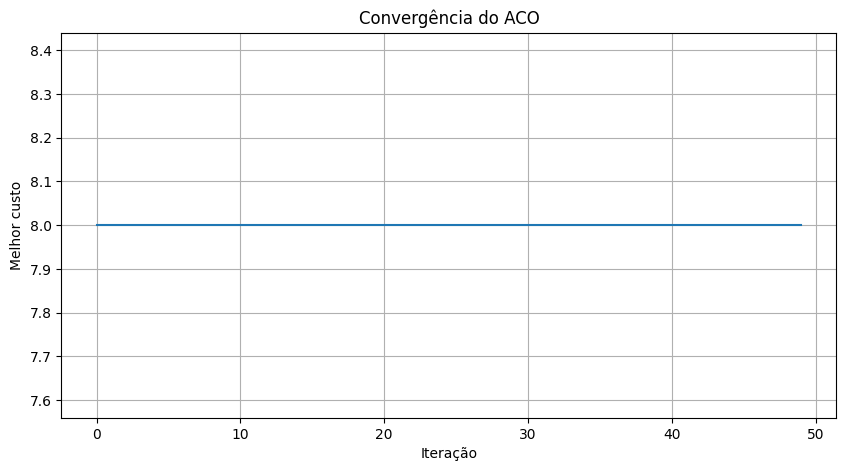

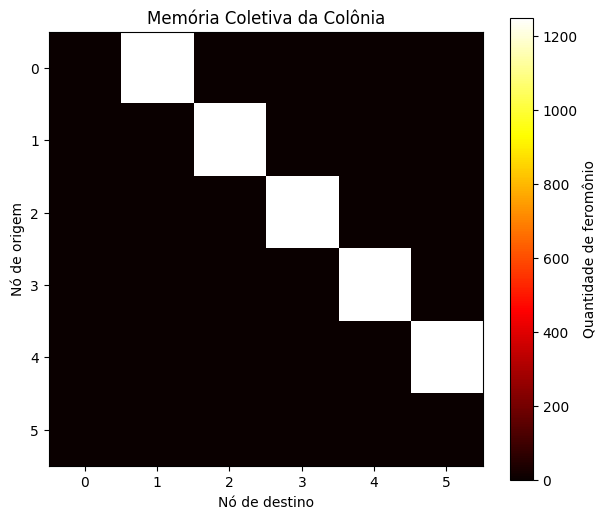


========== RESULTADO DO EXPERIMENTO ==========
Número de formigas: 50
Número de iterações: 50
ALPHA: 1.0
BETA: 2.0
Taxa de evaporação: 0.5
Melhor rota: [0, 1, 2, 3, 4, 5]
Melhor custo: 8.0


In [22]:
import numpy as np
import random
import matplotlib.pyplot as plt

# ============================================================
# PARÂMETROS DO EXPERIMENTO
# ============================================================

NUM_FORMIGAS = 50
NUM_ITERACOES = 50

ALPHA = 1.0
BETA = 2.0

TAXA_EVAPORACAO = 0.5
Q = 100

# ============================================================
# MATRIZ DE CUSTOS
# ============================================================

CUSTOS = np.array([
    [0, 2, 4, np.inf, np.inf, np.inf],
    [2, 0, 1, 5, np.inf, np.inf],
    [4, 1, 0, 2, 3, np.inf],
    [np.inf, 5, 2, 0, 1, 4],
    [np.inf, np.inf, 3, 1, 0, 2],
    [np.inf, np.inf, np.inf, 4, 2, 0]
])

ORIGEM = 0
DESTINO = 5


# ============================================================
# MATRIZ INICIAL DE FEROMÔNIO
# ============================================================

feromonio = np.ones_like(CUSTOS, dtype=float)
feromonio[CUSTOS == np.inf] = 0


# ============================================================
# FUNÇÃO PARA OBTER VIZINHOS
# ============================================================

def obter_vizinhos(no):
    vizinhos = []

    for proximo in range(len(CUSTOS)):
        if proximo != no and CUSTOS[no][proximo] != np.inf:
            vizinhos.append(proximo)

    return vizinhos


# ============================================================
# ESCOLHA DO PRÓXIMO NÓ
# ============================================================

def escolher_proximo(no_atual, visitados):

    vizinhos = obter_vizinhos(no_atual)

    candidatos = [
        no for no in vizinhos
        if no not in visitados
    ]

    if not candidatos:
        return None

    atratividades = []

    for proximo in candidatos:

        fer = feromonio[no_atual][proximo]
        custo = CUSTOS[no_atual][proximo]

        atratividade = (
            fer ** ALPHA
            * (1 / custo) ** BETA
        )

        atratividades.append(atratividade)

    soma = sum(atratividades)

    probabilidades = [
        valor / soma
        for valor in atratividades
    ]

    return random.choices(
        candidatos,
        weights=probabilidades,
        k=1
    )[0]


# ============================================================
# CONSTRUÇÃO DA ROTA
# ============================================================

def construir_rota():

    rota = [ORIGEM]
    atual = ORIGEM

    while atual != DESTINO:

        proximo = escolher_proximo(
            atual,
            rota
        )

        if proximo is None:
            return None

        rota.append(proximo)
        atual = proximo

    return rota


# ============================================================
# CÁLCULO DO CUSTO
# ============================================================

def calcular_custo(rota):

    total = 0

    for i in range(len(rota) - 1):

        origem = rota[i]
        destino = rota[i + 1]

        total += CUSTOS[origem][destino]

    return total


# ============================================================
# DEPÓSITO DE FEROMÔNIO
# ============================================================

def depositar_feromonio(rota, custo):

    deposito = Q / custo

    for i in range(len(rota) - 1):

        origem = rota[i]
        destino = rota[i + 1]

        feromonio[origem][destino] += deposito


# ============================================================
# EVAPORAÇÃO DO FEROMÔNIO
# ============================================================

def evaporar_feromonio():

    global feromonio

    feromonio *= (1 - TAXA_EVAPORACAO)

    feromonio[CUSTOS == np.inf] = 0


# ============================================================
# EXECUÇÃO DO ACO
# ============================================================

melhor_rota = None
melhor_custo = float("inf")

historico = []


for iteracao in range(NUM_ITERACOES):

    rotas = []

    for _ in range(NUM_FORMIGAS):

        rota = construir_rota()

        if rota is not None:

            custo = calcular_custo(rota)

            rotas.append((rota, custo))

            if custo < melhor_custo:

                melhor_custo = custo
                melhor_rota = rota.copy()

    evaporar_feromonio()

    for rota, custo in rotas:

        depositar_feromonio(
            rota,
            custo
        )

    historico.append(melhor_custo)


# ============================================================
# RESULTADO
# ============================================================

print("\n========== RESULTADO ==========")
print("Melhor rota encontrada:", melhor_rota)
print("Melhor custo:", melhor_custo)


# ============================================================
# GRÁFICO DE CONVERGÊNCIA
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(historico)

plt.xlabel("Iteração")
plt.ylabel("Melhor custo")

plt.title("Convergência do ACO")

plt.grid()

plt.show()


# ============================================================
# GRÁFICO DO FEROMÔNIO
# ============================================================

plt.figure(figsize=(7,6))

plt.imshow(
    feromonio,
    cmap="hot"
)

plt.colorbar(
    label="Quantidade de feromônio"
)

plt.xlabel("Nó de destino")
plt.ylabel("Nó de origem")

plt.title("Memória Coletiva da Colônia")

plt.show()


# ============================================================
# RESULTADO DO EXPERIMENTO
# ============================================================

print("\n========== RESULTADO DO EXPERIMENTO ==========")

print("Número de formigas:", NUM_FORMIGAS)
print("Número de iterações:", NUM_ITERACOES)
print("ALPHA:", ALPHA)
print("BETA:", BETA)
print("Taxa de evaporação:", TAXA_EVAPORACAO)
print("Melhor rota:", melhor_rota)
print("Melhor custo:", melhor_custo)

Resultados:

Experimento	Parâmetro	Resultado

1	ALPHA = 0,1	Rota [0,1,2,3,4,5] — custo 8,0

1	ALPHA = 1,0	Rota [0,1,2,3,4,5] — custo 8,0

1	ALPHA = 5,0	Rota [0,1,2,3,4,5] — custo 8,0

2	BETA = 0,5	Rota [0,1,2,3,4,5] — custo 8,0

2	BETA = 5,0	Rota [0,1,2,3,4,5] — custo 8,0

3	Evaporação = 0,1	Rota [0,1,2,4,5] — custo 8,0

3	Evaporação = 0,9	Rota [0,1,2,3,4,5] — custo 8,0

4	Formigas = 5	Rota [0,1,2,3,4,5] — custo 8,0

4	Formigas = 50	Rota [0,1,2,3,4,5] — custo 8,0


Respostas que você pode colocar no relatório


Experimento 1 — ALPHA

Quando aumentamos o ALPHA, aumenta a influência da experiência acumulada pelas formigas, representada pelo feromônio. Nos testes realizados, entretanto, o melhor custo permaneceu 8,0 e a melhor rota também permaneceu praticamente a mesma.

Experimento 2 — BETA

Quando o BETA aumenta, a influência da informação heurística, relacionada ao custo do caminho, aumenta. Assim, caminhos de menor custo tornam-se mais atrativos. Nos testes realizados, o melhor custo permaneceu 8,0.

Experimento 3 — Evaporação

Com uma taxa de evaporação alta, o algoritmo esquece mais rapidamente as experiências anteriores, pois o feromônio desaparece mais rapidamente. Com evaporação de 0,1 foi encontrada a rota [0,1,2,4,5], enquanto com 0,9 foi encontrada [0,1,2,3,4,5]. O custo permaneceu 8,0.

Experimento 4 — Número de formigas

Aumentar o número de formigas permite explorar mais soluções a cada iteração. No experimento, tanto com 5 quanto com 50 formigas foi encontrada a rota [0,1,2,3,4,5], com custo 8,0.